### 연관분석
Association Analysis in Python <br>
Frequent Item set Mining using Apriori algorithm in Python <br> <br>


> Apriori is an algorithm for frequent item set mining and association rule learning over relational databases. It proceeds by identifying the frequent individual items in the database and extending them to larger and larger item sets as long as those item sets appear sufficiently often in the database. The frequent item sets determined by Apriori can be used to determine association rules which highlight general trends in the database: this has applications in domains such as market basket analysis. <br>
-Apriori Algorithm, Wikipedia 2019.


출처 : https://medium.com/analytics-vidhya/association-analysis-in-python-2b955d0180c


In [2]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
## Use this to read data directly from github
df = pd.read_csv('https://gist.githubusercontent.com/Harsh-Git-Hub/2979ec48043928ad9033d8469928e751/raw/72de943e040b8bd0d087624b154d41b2ba9d9b60/retail_dataset.csv', sep=',')
## Use this to read data from the csv file on local system.
# df = pd.read_csv('./data/retail_data.csv', sep=',')
df = pd.read_csv('./retail_dataset.csv', sep=',')
## Print first 10 rows
df.head(10)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,0,1,2,3,4,5,6
0,Bread,Wine,Eggs,Meat,Cheese,Pencil,Diaper
1,Bread,Cheese,Meat,Diaper,Wine,Milk,Pencil
2,Cheese,Meat,Eggs,Milk,Wine,NaN,NaN
3,Cheese,Meat,Eggs,Milk,Wine,NaN,NaN
4,Meat,Pencil,Wine,NaN,NaN,NaN,NaN
5,Eggs,Bread,Wine,Pencil,Milk,Diaper,Bagel
6,Wine,Pencil,Eggs,Cheese,NaN,NaN,NaN
7,Bagel,Bread,Milk,Pencil,Diaper,NaN,NaN
8,Bread,Diaper,Cheese,Milk,Wine,Eggs,NaN
9,Bagel,Wine,Diaper,Meat,Pencil,Eggs,Cheese


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
df.shape

(315, 7)

In [11]:
items = set()
for col in df:
    items.update(df[col].unique())
print(items)

{'Meat', 'Bread', 'Diaper', nan, 'Wine', 'Milk', 'Eggs', 'Cheese', 'Bagel', 'Pencil'}


#### Data Preprocessing
-  One Hot Encode
> 원본 데이터는 장바구니 형태(한 행에 구매한 품목들이 나열된 형태)입니다.  
이를 ohe_df라는 0과 1의 이진(Binary) 데이터프레임으로 변환했습니다.

In [12]:
itemset = set(items)
encoded_vals = []
for index, row in df.iterrows():
    rowset = set(row)
    labels = {}
    uncommons = list(itemset - rowset)
    commons = list(itemset.intersection(rowset))
    for uc in uncommons:
        labels[uc] = 0
    for com in commons:
        labels[com] = 1
    encoded_vals.append(labels)
encoded_vals[0]
ohe_df = pd.DataFrame(encoded_vals)

In [22]:
ohe_df.head(2)

,Bagel,Milk,NaN,Meat,Bread,Diaper,Wine,Eggs,Cheese,Pencil
0,0,0,0,1,1,1,1,1,1,1
1,0,1,0,1,1,1,1,0,1,1


#### Applying Apriori
> apriori(df, min_support=0.5, use_colnames=False, max_len=None, verbose=0, low_memory=False)

- df : One-Hot-Encoded DataFrame or DataFrame that has 0 and 1 or True and False as values
- min_support : Floating point value between 0 and 1 that indicates the minimum support required for an itemset to be selected.
\# of observation with item / total observation# of observation with item / total observation
- use_colnames : This allows to preserve column names for itemset making it more readable.
- max_len : Max length of itemset generated. If not set, all possible lengths are evaluated.
- verbose : Shows the number of iterations if >= 1 and low_memory is True. If =1 and low_memory is False , shows the number of combinations.
- low_memory :
If True, uses an iterator to search for combinations above min_support.

In [35]:
# min_support=0.2로 설정하여
# 전체 거래 중 최소 20% 이상 등장한 품목(또는 품목 조합)을 추출했습니다.
freq_items = apriori(ohe_df, min_support=0.2, use_colnames=True, verbose=1)
freq_items.head(7)

Processing 8 combinations | Sampling itemset size 4


,support,itemsets
0,0.425397,(Bagel)
1,0.501587,(Milk)
2,0.869841,(nan)
3,0.476190,(Meat)
4,0.504762,(Bread)
5,0.406349,(Diaper)
6,0.438095,(Wine)


#### Mining Association Rules
Frequent if-then associations called association rules which consists of an antecedent (if) and a consequent (then).
> association_rules(df, metric='confidence', min_threshold=0.8, support_only=False)

- 지지도 (Support): 두 품목 A와 B가 동시에 구매될 확률
- 신뢰도 (Confidence): A를 샀을 때 B도 함께 살 확률
- 향상도 (Lift): A 구매가 B 구매를 얼마나 증가시키는지 나타내는 지표
  - $\text{Lift} > 1$: 양의 연관성 (A를 살 때 B도 같이 살 가능성이 높음)  
  - $\text{Lift} = 1$: 상호 독립
  - $\text{Lift} < 1$: 음의 연관성 (A를 살 때 B는 오히려 안 살 가능성이 높음)

<br>

결과 예시 해석 (Row 1): (Bagel) -> (Bread)
- Confidence (0.6567): 베이글을 산 고객 중 약 65.7%가 빵도 함께 구매
- Lift (1.3010): 베이글과 빵은 단순히 따로 살 때보다 함께 구매될 확률이 약 1.3배 높음 (양의 연관성).

In [36]:
# min_threshold=0.6 (신뢰도 60% 이상) 조건으로 연관규칙을 생성
rules = association_rules(freq_items, metric="confidence", min_threshold=0.6)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Bagel),(nan),0.425397,0.869841,0.336508,0.791045,0.909413,1.0,-0.033520,0.622902,-0.147743,0.350993,-0.605388,0.588953
1,(Bagel),(Bread),0.425397,0.504762,0.279365,0.656716,1.301042,1.0,0.064641,1.442650,0.402687,0.429268,0.306831,0.605088
2,(Milk),(nan),0.501587,0.869841,0.409524,0.816456,0.938626,1.0,-0.026778,0.709141,-0.115976,0.425743,-0.410157,0.643629
3,(Milk),(Cheese),0.501587,0.501587,0.304762,0.607595,1.211344,1.0,0.053172,1.270148,0.350053,0.436364,0.212690,0.607595
4,(Cheese),(Milk),0.501587,0.501587,0.304762,0.607595,1.211344,1.0,0.053172,1.270148,0.350053,0.436364,0.212690,0.607595


#### Visualizing results

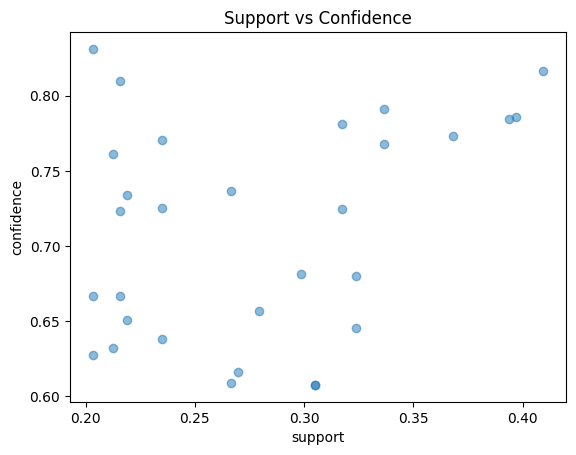

In [37]:
# Support vs Confidence
plt.scatter(rules['support'], rules['confidence'], alpha=0.5)
plt.xlabel('support')
plt.ylabel('confidence')
plt.title('Support vs Confidence')
plt.show()

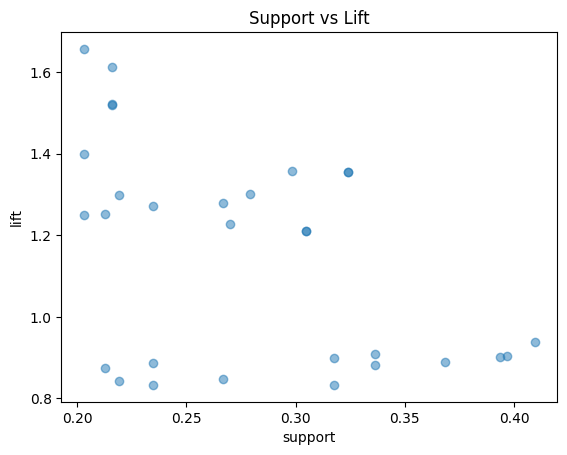

In [38]:
#  Support vs Lift
plt.scatter(rules['support'], rules['lift'], alpha=0.5)
plt.xlabel('support')
plt.ylabel('lift')
plt.title('Support vs Lift')
plt.show()

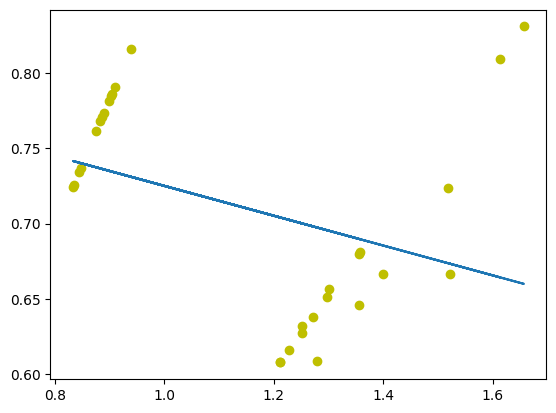

In [39]:
# Lift vs Confidence
fit = np.polyfit(rules['lift'], rules['confidence'], 1)
fit_fn = np.poly1d(fit)
plt.plot(rules['lift'], rules['confidence'], 'yo', rules['lift'],
 fit_fn(rules['lift']))

#### 추가확
전처리 보완, FP-Growth 적용, 향상도(Lift) 기준 정렬 및 네트워크 시각화

In [40]:
from mlxtend.frequent_patterns import fpgrowth
import networkx as nx

In [41]:
# NaN을 제외한 순수 아이템 리스트 추출
items = set()
for col in df.columns:
    items.update(df[col].dropna().unique())

In [42]:
# One-Hot Encoding (NaN 제외)
encoded_vals = []
for index, row in df.iterrows():
    rowset = set(row.dropna())
    labels = {item: (1 if item in rowset else 0) for item in items}
    encoded_vals.append(labels)

ohe_df = pd.DataFrame(encoded_vals)

In [43]:
# 2. FP-Growth 알고리즘 적용 (Apriori 대비 대용량 데이터 처리 속도 향상)
frequent_itemsets = fpgrowth(ohe_df, min_support=0.2, use_colnames=True)

In [44]:
# 품목 개수(length) 컬럼 추가
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

In [45]:
# 3. 연관규칙 생성 및 필터링 (Lift > 1.2, Confidence > 0.6)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
filtered_rules = rules[rules['lift'] > 1.2].sort_values(by='lift', ascending=False)

In [46]:
# frozenset을 보기 좋은 문자열로 변환
filtered_rules['antecedents_str'] = filtered_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
filtered_rules['consequents_str'] = filtered_rules['consequents'].apply(lambda x: ', '.join(list(x)))

In [47]:
print("=== 주요 연관 규칙 상위 5개 (Lift 기준) ===")
print(filtered_rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].head())

=== 주요 연관 규칙 상위 5개 (Lift 기준) ===
   antecedents_str consequents_str   support  confidence      lift
4       Milk, Meat          Cheese  0.203175    0.831169  1.657077
10      Meat, Eggs          Cheese  0.215873    0.809524  1.613924
12    Meat, Cheese            Eggs  0.215873    0.666667  1.521739
11    Eggs, Cheese            Meat  0.215873    0.723404  1.519149
5     Milk, Cheese            Meat  0.203175    0.666667  1.400000


In [48]:
# 4. 시각화: 네트워크 그래프 (NetworkX)
G = nx.DiGraph()

In [49]:
# 상위 연관 규칙만 그래프 노드/에지로 추가
top_rules = filtered_rules.head(15)
for idx, row in top_rules.iterrows():
    G.add_edge(row['antecedents_str'], row['consequents_str'], weight=row['lift'])

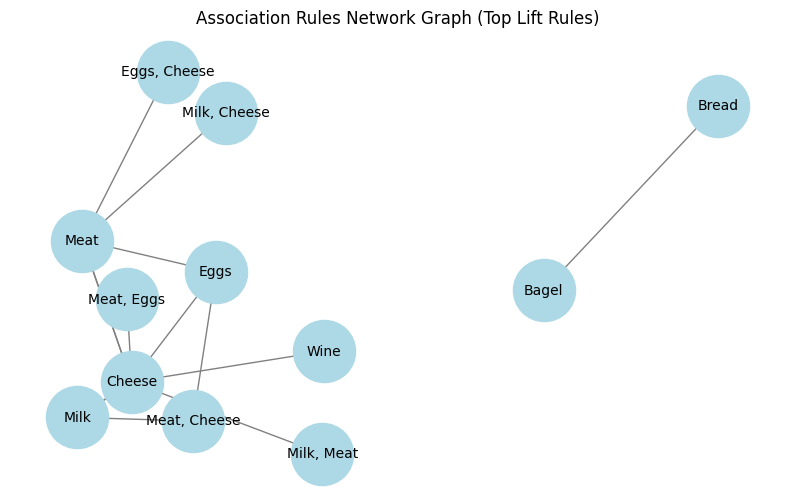

In [52]:
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, k=0.5)
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')

plt.title('Association Rules Network Graph (Top Lift Rules)')
plt.axis('off')
plt.show()


#### 비즈니스 활용 포인트
- 교차 판매(Cross-selling) / 번들 상품 출시: Lift와 Confidence가 모두 높은 품목을 패키지 상품으로 묶어 할인 판매합니다.

- 매장 진열 최적화: 함께 자주 구매되는 상품(Bagel과 Bread, Milk와 Cheese 등)을 서로 가까운 매대에 배치하거나, 반대로 매장 동선을 늘리기 위해 멀리 배치하는 전략을 취할 수 있습니다.
